In [3]:
# ============================================================
# 1) IMPORTS & CONFIG
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error




In [4]:
# ------------------------------
# CONFIG
# ------------------------------
PV_CSV_PATH = "pv_data.csv"
WEATHER_CSV_PATH = "weather_data.csv"

TARGET_COL = "pv"

ALL_FEATURES = [
    "soc","load","pv","sun_hours","temperature","glob_radiation_wm2",
    "hour_sin","hour_cos","dow_sin","dow_cos","woy_sin","woy_cos"
]

PAST_FEATURES = ALL_FEATURES.copy()

EXOG_FEATURES = [
    "temperature","sun_hours","glob_radiation_wm2",
    "hour_sin","hour_cos","dow_sin","dow_cos","woy_sin","woy_cos"
]

# Time-series lags (hours)
LAGS = [1, 2, 3, 6, 12]

In [5]:
# ============================================================
# 2) PREPROCESSING PIPELINE
# ============================================================

def load_and_merge():
    # --- Load PV data (5-min → hourly) ---
    pv_df = pd.read_csv(
        PV_CSV_PATH, sep=",",
        parse_dates=["timestamp"],
        index_col="timestamp"
    )
    pv_df = pv_df.apply(pd.to_numeric, errors="coerce")
    pv_hourly = pv_df.resample("1h").mean()

    # --- Load weather data ---
    weather_df = pd.read_csv(
        WEATHER_CSV_PATH,
        sep=",",
        parse_dates=["time"],
        index_col="time"
    )
    if weather_df.index.tz is not None:
        weather_df.index = weather_df.index.tz_convert(None)
    weather_df = weather_df.apply(pd.to_numeric, errors="coerce")

    # date range fix
    weather_df = weather_df.loc["2024-07-01":"2025-10-20"]

    # --- Merge PV + weather ---
    df = pv_hourly.join(weather_df, how="inner")

    # --- Time features ---
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["weekofyear"] = df.index.isocalendar().week

    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["dow_sin"]  = np.sin(2*np.pi*df["dayofweek"]/7)
    df["dow_cos"]  = np.cos(2*np.pi*df["dayofweek"]/7)
    df["woy_sin"]  = np.sin(2*np.pi*df["weekofyear"]/52)
    df["woy_cos"]  = np.cos(2*np.pi*df["weekofyear"]/52)

    df = df[ALL_FEATURES]
    df = df.replace(["None","nan","NaN",""], pd.NA).ffill().bfill()

    return df


def scale_and_split(df):
    split_train = int(len(df) * 0.7)
    split_val   = int(len(df) * 0.85)

    df_train = df.iloc[:split_train]
    df_val   = df.iloc[split_train:split_val]
    df_test  = df.iloc[split_val:]

    scaler_y = StandardScaler()
    scaler_X = StandardScaler()

    scaler_y.fit(df_train[[TARGET_COL]])
    scaler_X.fit(df_train[PAST_FEATURES])

    df_scaled = df.copy()
    df_scaled[PAST_FEATURES] = scaler_X.transform(df[PAST_FEATURES])
    df_scaled[TARGET_COL] = scaler_y.transform(df[[TARGET_COL]])

    return df_scaled, scaler_y, scaler_X, split_train, split_val


def create_lag_features(df_scaled, split_train, split_val):

    df_ml = df_scaled.copy()

    # --- build lags ---
    for lag in LAGS:
        for col in PAST_FEATURES:
            df_ml[f"{col}_lag{lag}"] = df_ml[col].shift(lag)

    df_ml = df_ml.dropna()

    # --- ML split ---
    df_train_ml = df_ml.iloc[:split_train]
    df_val_ml   = df_ml.iloc[split_train:split_val]
    df_test_ml  = df_ml.iloc[split_val:]

    FEATURE_COLS = [c for c in df_ml.columns if "lag" in c]

    X_train = df_train_ml[FEATURE_COLS]
    y_train = df_train_ml[TARGET_COL]
    X_val   = df_val_ml[FEATURE_COLS]
    y_val   = df_val_ml[TARGET_COL]
    X_test  = df_test_ml[FEATURE_COLS]
    y_test  = df_test_ml[TARGET_COL]

    return X_train, y_train, X_val, y_val, X_test, y_test, FEATURE_COLS


# ============================================================
# MAIN PREPROCESS FUNCTION
# ============================================================

def preprocess_all():
    df = load_and_merge()
    df_scaled, scaler_y, scaler_X, split_train, split_val = scale_and_split(df)
    X_train, y_train, X_val, y_val, X_test, y_test, FEATURES = create_lag_features(
        df_scaled, split_train, split_val
    )

    return (
        df, df_scaled,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        scaler_y, FEATURES
    )


# Run preprocessing
(
    df, df_scaled,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    scaler_y, FEATURES
) = preprocess_all()

print("Shapes:")
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


Shapes:
Train: (8013, 60)
Val:   (1717, 60)
Test:  (1706, 60)


Val RMSE: 15.000916644734522
Test RMSE: 13.137537889626344


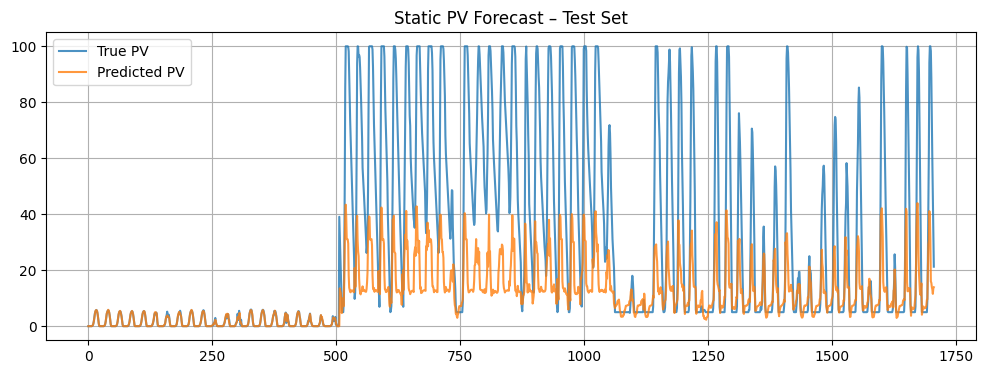

Next-step PV prediction: 13.899317703612708


In [7]:
# ============================================================
# 3) MODEL TRAINING + EVAL
# ============================================================

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# --- Predictions ---
pred_val = model.predict(X_val)
pred_test = model.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Val RMSE:", rmse(y_val, pred_val))
print("Test RMSE:", rmse(y_test, pred_test))


# ============================================================
# INVERSE SCALE & PLOT
# ============================================================
# Inverse scale for plotting
pred_test_inv = scaler_y.inverse_transform(pred_test.reshape(-1,1)).flatten()
y_test_inv    = scaler_y.inverse_transform(y_test.values.reshape(-1,1)).flatten()

plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label="True PV", alpha=0.8)
plt.plot(pred_test_inv, label="Predicted PV", alpha=0.8)
plt.legend()
plt.grid(True)
plt.title("Static PV Forecast – Test Set")
plt.show()

# Next-step prediction
next_pred_scaled = model.predict(X_test.iloc[-1:])[0]
next_pred = scaler_y.inverse_transform([[next_pred_scaled]])[0][0]
print("Next-step PV prediction:", next_pred)
